# NeuroVoz — GDBFNet con compuerta (corregido)

Versión coherente con PC-GITA. Corrige dos incoherencias del notebook original de
NeuroVoz:

1. **Modelo.** Usa `DualBranchFusionNet` (GDBFNet, con compuerta de fusión aprendida
   $\alpha$), el mismo de PC-GITA, en lugar de la concatenación sin puerta.
2. **Umbral.** Todas las métricas dependientes de umbral (accuracy, sensibilidad,
   especificidad) se calculan en el mismo punto de operación, el del índice de Youden.

Reutiliza el pipeline de embeddings de NeuroVoz y la función de entrenamiento de
PC-GITA (`train_fold_regularized`), de modo que ambos corpus comparten arquitectura,
entrenamiento y criterio de decisión. Produce: estimación robusta (CV repetida +
\emph{bootstrap}) con y sin ICMM, el coeficiente $\alpha$ de la compuerta, y las
figuras `res_roc_nv.png` y `res_confusion_nv.png` en `images/`.

In [1]:
# =============================== CONFIGURACIÓN ===============================
import os, sys, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = "/Users/napster/Documents/upm"
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

IMAGES_DIR = os.path.join(PROJECT_ROOT, "images")   # carpeta de figuras de la memoria
os.makedirs(IMAGES_DIR, exist_ok=True)

import numpy as np
import torch

TARGET_SR    = 16_000
TASK         = "PATAKA"
RANDOM_STATE = 42
N_FOLDS      = 5
N_REPEATS    = 10          # CV repetida para la estimación robusta (como PC-GITA)
N_TRIALS     = 75          # Optuna, igual que PC-GITA

QUICK = False              # True -> prueba rápida
if QUICK:
    N_TRIALS, N_REPEATS = 12, 3
EPOCHS   = 40 if QUICK else 120
PATIENCE = 10 if QUICK else 20

NEUROVOZ_ROOT = "data/neurovoz"
AUDIO_DIR = f"{NEUROVOZ_ROOT}/audios"
META_HC   = f"{NEUROVOZ_ROOT}/metadata/metadata_hc.csv"
META_PD   = f"{NEUROVOZ_ROOT}/metadata/metadata_pd.csv"

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)

CACHE = os.path.join(PROJECT_ROOT, "nested_cache"); os.makedirs(CACHE, exist_ok=True)
print(f"device={DEVICE} | imágenes -> {IMAGES_DIR}")

device=mps | imágenes -> /Users/napster/Documents/upm/images


## 1 — Embeddings de NeuroVoz (todos los sujetos)

Se usa el 100\% de los sujetos en la validación cruzada, igual que en PC-GITA
(sin holdout), para que la estimación robusta sea directamente comparable. Cacheado.

In [2]:
# =========================== EMBEDDINGS (con cache) ===========================
import pandas as pd
from sklearn.preprocessing import StandardScaler

cache_file = os.path.join(CACHE, "neurovoz_all.npz")

if os.path.exists(cache_file):
    d = np.load(cache_file)
    emb_t_all, emb_s_all, labels_all = d["emb_t"], d["emb_s"], d["labels"]
    print(f"Cargado de cache: {cache_file}")
else:
    from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
    from src.spectral import extract_spectral_features
    import soundfile as sf
    from math import gcd
    from scipy.signal import resample_poly

    def load_neurovoz_metadata(meta_hc_path, meta_pd_path, task=TASK):
        hc = pd.read_csv(meta_hc_path); pd_ = pd.read_csv(meta_pd_path)
        df = pd.concat([hc, pd_], ignore_index=True)
        df["filename"] = df["Audio"].str.split("/").str[-1]
        df["task"] = df["filename"].str.extract(r"^[A-Z]+_(.+)_\d+\.wav")
        df = df[df["task"] == task].copy()
        df["label"] = (df["Group"] == "PD").astype(int)
        df["audio_path"] = df["filename"].apply(lambda f: os.path.join(AUDIO_DIR, f))
        return df[["label", "audio_path"]].reset_index(drop=True)

    def load_and_resample(path, target_sr=TARGET_SR):
        wav, sr = sf.read(path, dtype="float32", always_2d=False)
        if wav.ndim > 1: wav = wav.mean(axis=1)
        if sr != target_sr:
            g = gcd(sr, target_sr); wav = resample_poly(wav, target_sr // g, sr // g)
        return wav.astype(np.float32)

    def preprocess_waveform(x, pre_emphasis=0.97):
        x = x - np.mean(x)
        x = np.append(x[0], x[1:] - pre_emphasis * x[:-1])
        peak = np.max(np.abs(x))
        return x / peak if peak > 0 else x

    def extract_wav2vec2_embeddings(waveforms, model_id="facebook/wav2vec2-base", layer=0, device=DEVICE):
        extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_id)
        model = Wav2Vec2Model.from_pretrained(model_id, output_hidden_states=True).to(device).eval()
        embs = []
        with torch.no_grad():
            for wav in waveforms:
                iv = extractor(wav, sampling_rate=TARGET_SR, return_tensors="pt").input_values.to(device)
                h = model(iv).hidden_states[layer].squeeze(0)
                embs.append(h.mean(dim=0).cpu().numpy())
        return np.stack(embs)

    df_meta = load_neurovoz_metadata(META_HC, META_PD, TASK)
    waveforms = [preprocess_waveform(load_and_resample(p)) for p in df_meta["audio_path"]]
    labels = df_meta["label"].to_numpy()

    emb_w2v = extract_wav2vec2_embeddings(waveforms, layer=0, device=DEVICE)
    spectral = extract_spectral_features(waveforms, device=DEVICE)

    emb_t_all = StandardScaler().fit_transform(emb_w2v)
    emb_s_all = StandardScaler().fit_transform(spectral)
    labels_all = labels
    np.savez(cache_file, emb_t=emb_t_all, emb_s=emb_s_all, labels=labels_all)
    print(f"Extraído y cacheado: {cache_file}")

labels_all = labels_all.astype(np.float32)
print(f"Sujetos: {len(labels_all)} | PD={int(labels_all.sum())} HC={int((labels_all==0).sum())} "
      f"| dim_t={emb_t_all.shape[1]} dim_s={emb_s_all.shape[1]}")

2026-07-08 22:00:39,851 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-07-08 22:00:39,950 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-08 22:00:40,015 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/preprocessor_config.json "HTTP/1.1 200 OK"
2026-07-08 22:00:40,115 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-08 22:00:40,117 [WARNING] huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-08 22:00:40,180 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/res

Extraído y cacheado: /Users/napster/Documents/upm/nested_cache/neurovoz_all.npz
Sujetos: 99 | PD=49 HC=50 | dim_t=768 dim_s=512


## 2 — GDBFNet con compuerta y entrenamiento (idéntico a PC-GITA)

Se importa `DualBranchFusionNet` de `src.models` y se emplea la misma
`train_fold_regularized` que PC-GITA, que devuelve también los coeficientes $\alpha$
de la compuerta. Todas las métricas se evalúan en el umbral de Youden.

In [3]:
# ==================== MODELO, ENTRENAMIENTO Y MÉTRICAS ====================
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

from src.models import DualBranchFusionNet   # GDBFNet con compuerta (mismo que PC-GITA)

class DualBranchDataset(Dataset):
    def __init__(self, emb_t, emb_s, labels, idx):
        self.emb_t = torch.tensor(emb_t[idx], dtype=torch.float32)
        self.emb_s = torch.tensor(emb_s[idx], dtype=torch.float32)
        self.labels = torch.tensor(labels[idx], dtype=torch.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.emb_t[i], self.emb_s[i], self.labels[i]

def train_fold_regularized(train_ds, val_ds, device,
                           lr=1e-3, weight_decay=1e-4, label_smoothing=0.0,
                           dropout=0.3, dim_proj=128, dim_hidden=64,
                           epochs=120, patience=20, batch_size=8,
                           scheduler_factor=0.5, scheduler_patience=7):
    """Réplica exacta de la función de PC-GITA; devuelve (y_true, y_prob, alphas, history)."""
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=len(val_ds))
    model = DualBranchFusionNet(dim_proj=dim_proj, dim_hidden=dim_hidden, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=scheduler_factor, patience=scheduler_patience)
    best_val_loss, epochs_no_improve, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "lr": []}
    for epoch in range(epochs):
        model.train(); train_losses = []
        for z_t, z_s, y in train_loader:
            z_t, z_s, y = z_t.to(device), z_s.to(device), y.to(device)
            if label_smoothing > 0:
                y = y * (1 - label_smoothing) + label_smoothing / 2
            logits, _ = model(z_t, z_s)
            loss = criterion(logits, y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            z_t_v, z_s_v, y_v = next(iter(val_loader))
            z_t_v, z_s_v, y_v = z_t_v.to(device), z_s_v.to(device), y_v.to(device)
            logits_v, alphas_v = model(z_t_v, z_s_v)
            val_loss = criterion(logits_v, y_v).item()
        scheduler.step(val_loss)
        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(val_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        if val_loss < best_val_loss:
            best_val_loss, epochs_no_improve = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        z_t_v, z_s_v, y_v = next(iter(val_loader))
        z_t_v, z_s_v, y_v = z_t_v.to(device), z_s_v.to(device), y_v.to(device)
        logits_v, alphas_v = model(z_t_v, z_s_v)
        y_prob = torch.sigmoid(logits_v).cpu().numpy()
        y_true = y_v.cpu().numpy()
        alphas = alphas_v.cpu().numpy()
    return y_true, y_prob, alphas, history

def manifold_mixup_intraclass(emb_t, emb_s, labels, alpha, rng):
    aug_t, aug_s, aug_labels = [], [], []
    for cls in [0, 1]:
        cls_idx = np.where(labels == cls)[0]
        if len(cls_idx) < 2: continue
        for i in cls_idx:
            j = rng.choice(cls_idx[cls_idx != i])
            lam = rng.beta(alpha, alpha)
            aug_t.append(lam * emb_t[i] + (1 - lam) * emb_t[j])
            aug_s.append(lam * emb_s[i] + (1 - lam) * emb_s[j])
            aug_labels.append(cls)
    return np.array(aug_t), np.array(aug_s), np.array(aug_labels)

def youden_metrics(y_true, y_prob):
    """Las cuatro métricas en el MISMO punto de operación (índice de Youden)."""
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    t = thr[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= t).astype(int)
    return dict(auc=roc_auc_score(y_true, y_prob),
                acc=accuracy_score(y_true, y_pred),
                sens=recall_score(y_true, y_pred, pos_label=1, zero_division=0),
                spec=recall_score(y_true, y_pred, pos_label=0, zero_division=0),
                thr=float(t))

def build_train_ds(tr_idx, use_icmm, mixup_alpha, seed):
    tr_t, tr_s, tr_l = emb_t_all[tr_idx], emb_s_all[tr_idx], labels_all[tr_idx]
    if use_icmm:
        rng = np.random.default_rng(seed)
        at, as_, al = manifold_mixup_intraclass(tr_t, tr_s, tr_l, mixup_alpha, rng)
        tr_t = np.concatenate([tr_t, at]); tr_s = np.concatenate([tr_s, as_]); tr_l = np.concatenate([tr_l, al])
    return DualBranchDataset(tr_t, tr_s, tr_l, np.arange(len(tr_l)))

def bootstrap_ci(vals, n_boot=1000, ci=95, seed=42):
    rng = np.random.default_rng(seed); vals = np.asarray(vals)
    b = [rng.choice(vals, len(vals), replace=True).mean() for _ in range(n_boot)]
    return vals.mean(), np.percentile(b, (100-ci)/2), np.percentile(b, 100-(100-ci)/2)

## 3 — Optimización de hiperparámetros (Optuna)

Mismo espacio de búsqueda que PC-GITA, con $\alpha$ de ICMM co-optimizado. El
objetivo es el AUC (independiente del umbral), por lo que la selección no se ve
afectada por el punto de operación.

In [4]:
# ================================ OPTUNA ================================
import optuna
from sklearn.model_selection import StratifiedKFold
optuna.logging.set_verbosity(optuna.logging.WARNING)

def search_space(trial):
    return dict(
        lr=trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        weight_decay=trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
        dropout=trial.suggest_float("dropout", 0.1, 0.5, step=0.05),
        label_smoothing=trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.025),
        batch_size=trial.suggest_categorical("batch_size", [8, 16, 32]),
        dim_proj=trial.suggest_categorical("dim_proj", [64, 128, 256]),
        dim_hidden=trial.suggest_categorical("dim_hidden", [32, 64, 128]),
        mixup_alpha=trial.suggest_float("mixup_alpha", 0.1, 1.0, step=0.1),
    )

def objective(trial):
    hp = search_space(trial); ma = hp.pop("mixup_alpha")
    skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs = []
    for k, (tr, va) in enumerate(skf.split(emb_t_all, labels_all)):
        train_ds = build_train_ds(tr, True, ma, RANDOM_STATE + k)
        val_ds = DualBranchDataset(emb_t_all, emb_s_all, labels_all, va)
        yt, yp, _, _ = train_fold_regularized(train_ds, val_ds, DEVICE,
                                              epochs=EPOCHS, patience=PATIENCE, **hp)
        aucs.append(roc_auc_score(yt, yp))
    return np.mean(aucs) - 0.5 * np.std(aucs)

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

bp = study.best_params
mixup_alpha = bp.pop("mixup_alpha")
bp_model = {**bp, "epochs": EPOCHS, "patience": PATIENCE}
print("Mejores hiperparámetros:", bp_model, "| mixup_alpha:", mixup_alpha)

Best trial: 65. Best value: 0.89493: 100%|██████████| 75/75 [07:02<00:00,  5.64s/it] 

Mejores hiperparámetros: {'lr': 0.00013399386986704407, 'weight_decay': 0.00014105798518437992, 'dropout': 0.15000000000000002, 'label_smoothing': 0.15, 'batch_size': 16, 'dim_proj': 256, 'dim_hidden': 128, 'epochs': 120, 'patience': 20} | mixup_alpha: 0.4


## 4 — Estimación robusta (CV repetida + bootstrap), con y sin ICMM

Métricas en el umbral de Youden. Se reporta también el coeficiente medio $\alpha$ de
la compuerta, análogo al de PC-GITA.

In [5]:
# ===================== CV REPETIDA (Youden) + BOOTSTRAP =====================
from sklearn.model_selection import RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
res = {"base": {"auc": [], "acc": [], "sens": [], "spec": []},
       "icmm": {"auc": [], "acc": [], "sens": [], "spec": []}}
alphas_all = []

for k, (tr, va) in enumerate(rskf.split(emb_t_all, labels_all)):
    val_ds = DualBranchDataset(emb_t_all, emb_s_all, labels_all, va)
    # Sin ICMM
    yt, yp, _, _ = train_fold_regularized(
        build_train_ds(tr, False, None, 0), val_ds, DEVICE, **bp_model)
    m = youden_metrics(yt, yp)
    for kk in res["base"]: res["base"][kk].append(m[kk])
    # Con ICMM
    yt, yp, al, _ = train_fold_regularized(
        build_train_ds(tr, True, mixup_alpha, RANDOM_STATE + k), val_ds, DEVICE, **bp_model)
    m = youden_metrics(yt, yp)
    for kk in res["icmm"]: res["icmm"][kk].append(m[kk])
    alphas_all.append(float(np.mean(al)))

print("=" * 70)
print("NeuroVoz — GDBFNet con compuerta (Youden) | CV repetida + IC 95% bootstrap")
print("=" * 70)
print(f"  {'Métrica':<14}{'GDBFNet':>26}{'GDBFNet + ICMM':>26}")
print("  " + "-" * 66)
for kk, name in zip(["auc","acc","sens","spec"], ["AUC","Exactitud","Sensibilidad","Especificidad"]):
    mb, lb, hb = bootstrap_ci(res["base"][kk]); mi, li, hi = bootstrap_ci(res["icmm"][kk])
    print(f"  {name:<14}{mb:.3f} [{lb:.3f}, {hb:.3f}]   {mi:.3f} [{li:.3f}, {hi:.3f}]")
print("  " + "-" * 66)
print(f"  Coeficiente de compuerta alpha (media): {np.mean(alphas_all):.3f}")

NeuroVoz — GDBFNet con compuerta (Youden) | CV repetida + IC 95% bootstrap
  Métrica                          GDBFNet            GDBFNet + ICMM
  ------------------------------------------------------------------
  AUC           0.910 [0.891, 0.928]   0.915 [0.900, 0.930]
  Exactitud     0.889 [0.871, 0.905]   0.887 [0.872, 0.901]
  Sensibilidad  0.888 [0.864, 0.912]   0.886 [0.864, 0.909]
  Especificidad 0.890 [0.858, 0.918]   0.888 [0.862, 0.912]
  ------------------------------------------------------------------
  Coeficiente de compuerta alpha (media): 0.584


## 5 — Figuras coherentes: ROC y matriz de confusión (umbral de Youden)

Predicciones fuera de muestra con GDBFNet + ICMM; se guardan en `images/`.

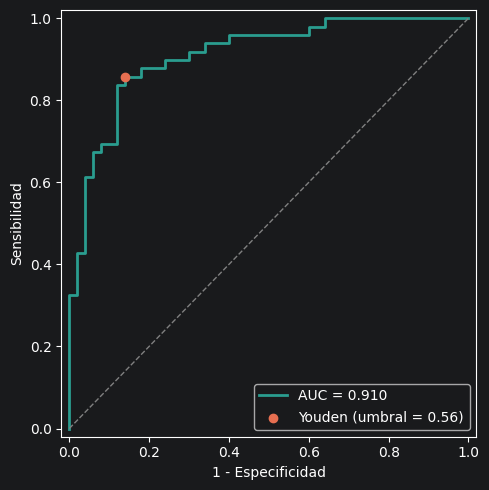

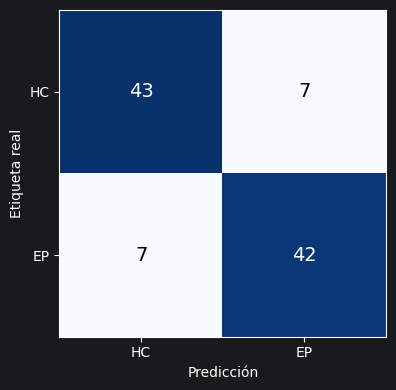

OOF AUC=0.910 | umbral Youden=0.56
Guardadas: /Users/napster/Documents/upm/images/res_roc_nv.png | /Users/napster/Documents/upm/images/res_confusion_nv.png


In [6]:
# ============ OOF -> ROC y matriz de confusión (Youden), a images/ ============
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_true, oof_prob = [], []
for k, (tr, va) in enumerate(skf.split(emb_t_all, labels_all)):
    val_ds = DualBranchDataset(emb_t_all, emb_s_all, labels_all, va)
    yt, yp, _, _ = train_fold_regularized(
        build_train_ds(tr, True, mixup_alpha, RANDOM_STATE + k), val_ds, DEVICE, **bp_model)
    oof_true.append(yt); oof_prob.append(yp)
oof_true = np.concatenate(oof_true); oof_prob = np.concatenate(oof_prob)

fpr, tpr, thr = roc_curve(oof_true, oof_prob)
auc = roc_auc_score(oof_true, oof_prob)
j = np.argmax(tpr - fpr); youden_thr = thr[j]

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#2A9D8F", lw=2, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
ax.scatter(fpr[j], tpr[j], color="#E76F51", zorder=5, label=f"Youden (umbral = {youden_thr:.2f})")
ax.set_xlabel("1 - Especificidad"); ax.set_ylabel("Sensibilidad")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.legend(loc="lower right")
plt.tight_layout()
roc_path = os.path.join(IMAGES_DIR, "res_roc_nv.png")
plt.savefig(roc_path, dpi=200, bbox_inches="tight"); plt.show()

y_pred = (oof_prob >= youden_thr).astype(int)
cm = confusion_matrix(oof_true, y_pred)
fig, ax = plt.subplots(figsize=(4.2, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["HC", "EP"]); ax.set_yticklabels(["HC", "EP"])
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
for r in range(2):
    for c in range(2):
        ax.text(c, r, int(cm[r, c]), ha="center", va="center", fontsize=14,
                color="white" if cm[r, c] > cm.max() / 2 else "black")
plt.tight_layout()
cm_path = os.path.join(IMAGES_DIR, "res_confusion_nv.png")
plt.savefig(cm_path, dpi=200, bbox_inches="tight"); plt.show()

print(f"OOF AUC={auc:.3f} | umbral Youden={youden_thr:.2f}")
print("Guardadas:", roc_path, "|", cm_path)